In [1]:
import torch
from torch import nn


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"


if image_path.is_dir():
    print(f"{image_path} directory exists.")
    print("Skipping download.")
else:
    print(f"{image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")
    zip_ref
    zip_ref.extractall(image_path)


data/pizza_steak_sushi does not exist, creating one...
Unzipping pizza, steak, sushi data...


In [4]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Image class : pizza
Image height : 512 , Image width 384


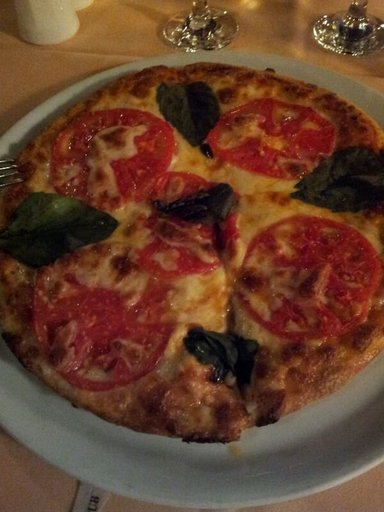

In [6]:
import random
from PIL import Image
ran_dir = random.choice(os.listdir(train_dir))

img = random.choice(os.listdir(train_dir / ran_dir))
img_path = train_dir / ran_dir / img
image_class = img_path.parent.stem
img = Image.open(img_path)
print(f"Image class : {image_class}")
print(f"Image height : {img.height} , Image width {img.width}")
img

(-0.5, 383.5, 511.5, -0.5)

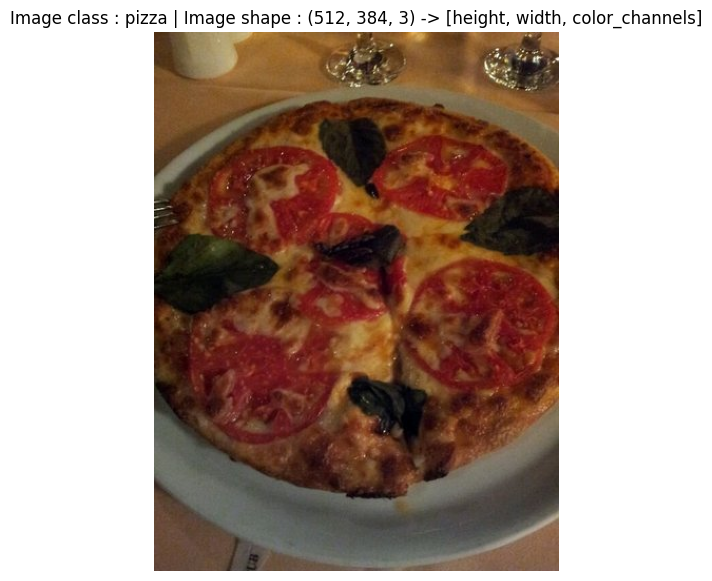

In [7]:
import matplotlib.pyplot as plt
import numpy as np


img_as_array = np.asarray(img)
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class : {image_class} | Image shape : {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

array([[[ 80,  49,  21],
        [ 78,  47,  19],
        [ 76,  45,  16],
        ...,
        [161, 109,  70],
        [160, 108,  69],
        [163, 111,  72]],

       [[ 77,  46,  18],
        [ 78,  47,  19],
        [ 78,  47,  18],
        ...,
        [161, 109,  70],
        [160, 108,  69],
        [164, 112,  73]],

       [[ 75,  44,  16],
        [ 77,  46,  18],
        [ 79,  48,  20],
        ...,
        [160, 108,  68],
        [160, 108,  68],
        [164, 112,  72]],

       ...,

       [[ 91,  64,  53],
        [ 95,  68,  57],
        [ 97,  70,  59],
        ...,
        [130,  97,  80],
        [132,  99,  82],
        [127,  94,  77]],

       [[ 95,  68,  57],
        [ 96,  69,  58],
        [ 99,  72,  61],
        ...,
        [129,  96,  81],
        [131,  98,  83],
        [127,  94,  79]],

       [[ 95,  68,  57],
        [ 95,  68,  57],
        [ 98,  71,  60],
        ...,
        [127,  94,  79],
        [129,  96,  81],
        [126,  93,  78]]], dtype=uint8)
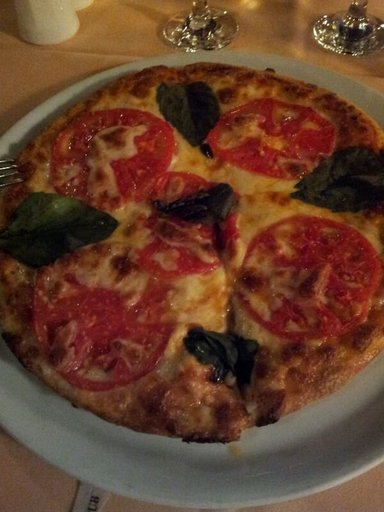

In [8]:
img_as_array

Time to transform the data


In [9]:
from torchvision import transforms,datasets
from torch.utils.data import DataLoader


data_transform = transforms.Compose([
    #Resize our images to 64x64
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    #Normalize our images
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [10]:
data_transform(img).shape


torch.Size([3, 64, 64])

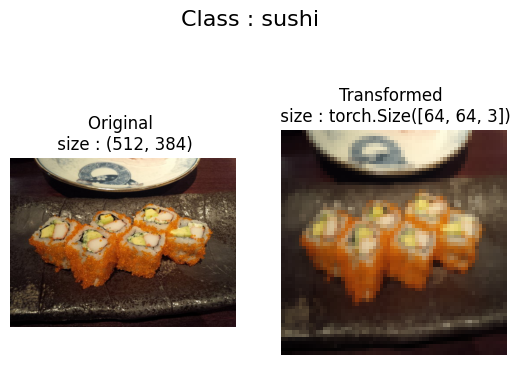

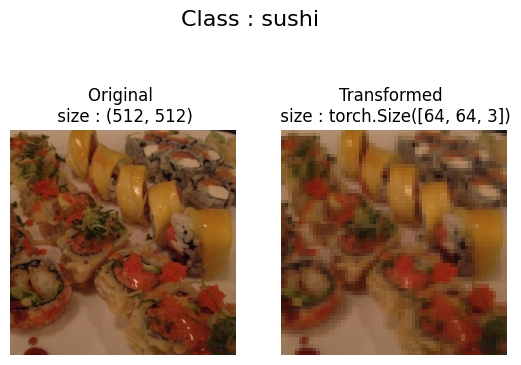

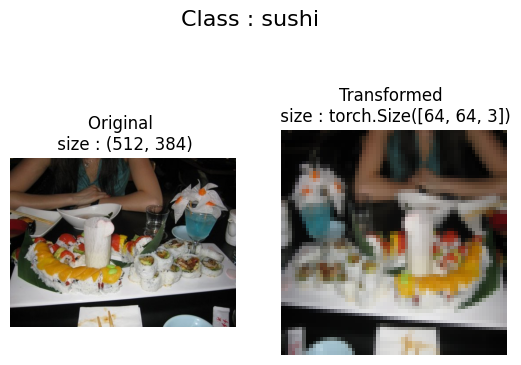

In [11]:
def plot_transformed_images(images_dir, transform, n=3, seed=42):
    if seed:
      random.seed(seed)
    random_images_paths = random.sample(os.listdir(images_dir), k=n)
    for image in random_images_paths:
        image_path = images_dir / image
        with Image.open(image_path) as img:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(img)
            ax[0].set_title(f"Original \n size : {img.size}")
            ax[0].axis("off")

            transformed_image = transform(img).permute(1, 2, 0) #permute is used to switching around the axes
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \n size : {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class : {image_path.parent.stem}", fontsize=16)



plot_transformed_images(train_dir / "sushi",transform= data_transform, n=3)

In [12]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)


train_data, test_data




(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [13]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [14]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [15]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image Tensor:\n{img}")
print(f"Image shape : {img.shape} -> [color_channels, height, width]")
print(f"Image label : {label}")

Image Tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

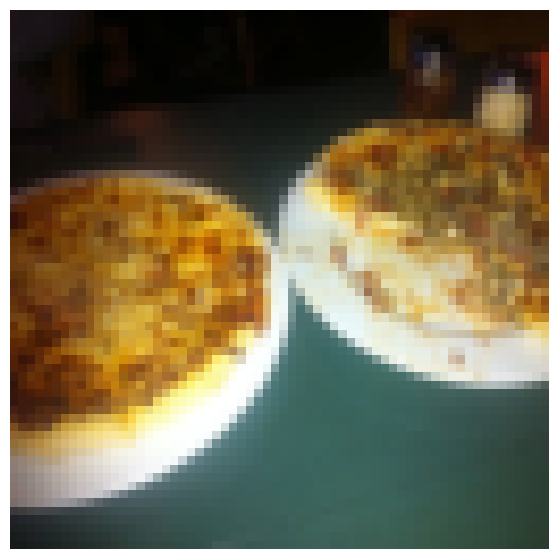

In [16]:
img_permute = img.permute(1, 2, 0)
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt

In [17]:
import os
os.cpu_count()

2

In [18]:
import torch
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=1, pin_memory=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c470ce115d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7c470ce10f40>)

In [19]:
len(train_dataloader), len(test_dataloader) ,len(train_data), len(test_data)

(8, 3, 225, 75)

In [20]:
img ,label = next(iter(train_dataloader))
img.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [21]:
from PIL import Image
from torch.utils.data import DataLoader
from typing import List, Tuple

In [22]:
target_dirctory = train_dir
print(f"Target dir: {target_dirctory}")

class_names_found = sorted(entry.name for entry in list(os.scandir(target_dirctory)))
print(f"Classes : {class_names_found}")

Target dir: data/pizza_steak_sushi/train
Classes : ['pizza', 'steak', 'sushi']


In [23]:
def find_classes(directory: str) -> Tuple[List[str], dict]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx



find_classes(target_dirctory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [24]:
class ImageFolderCustom(datasets.ImageFolder):
    def __init__(self,targ_dir: str , transform=None):
        self.paths = list(Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)
        self.root = targ_dir

    def load_image(self,index : int) -> Image.Image:
      image_path = self.paths[index]
      return Image.open(image_path)

    def __len__(self) -> int:
      return len(self.paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
      img = self.load_image(index)
      class_name = self.paths[index].parent.name
      class_idx = self.class_to_idx[class_name]

      if self.transform:
        return self.transform(img), class_idx
      else:
        return img, class_idx


In [25]:
train_transform = transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.ToTensor()])


test_transform = transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.ToTensor()])

In [26]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir, transform=train_transform)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, transform=test_transform)

In [27]:
train_data_custom

Dataset ImageFolderCustom
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train

In [28]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [29]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [30]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes : List[str] = None,
                          n : int = 10,
                          display_shape : bool = True,
                          seed : int = None):

  if n > 10:
    n= 10
    display_shape = False
    print(f"For display, purposes, n shouldn't be larger than 10, setting to 10 and removing shape display")
  if seed:
    torch.manual_seed(seed)

  random_samples_idx = random.sample(range(len(dataset)), k=n)

  plt.figure(figsize=(16, 8))

  for i,targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    targ_image_adjust = targ_image.permute(1, 2, 0)
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    if classes:
      title = f"class : {classes[targ_label]}"
      if display_shape:
        title = f"class : {classes[targ_label]} | shape : {targ_image_adjust.shape}"
    plt.title(title)


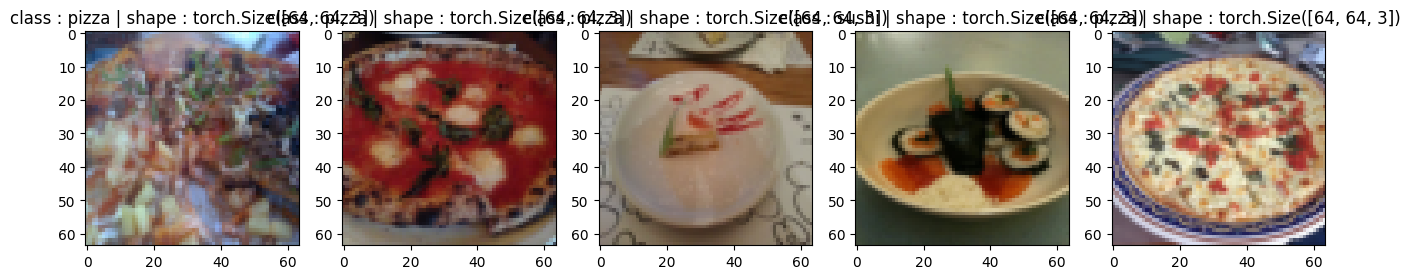

In [31]:
display_random_images(train_data, n=5, classes = class_names,seed=42)

For display, purposes, n shouldn't be larger than 10, setting to 10 and removing shape display


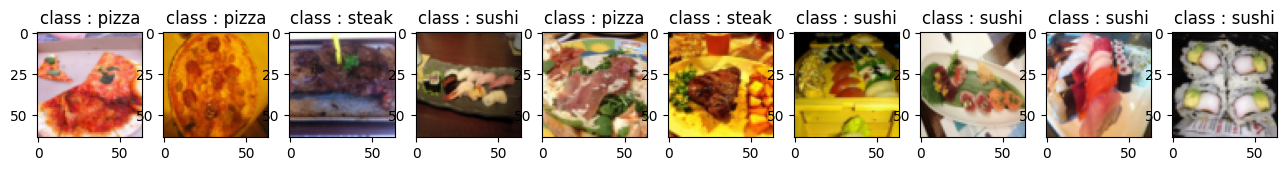

In [32]:
display_random_images(train_data_custom, n=20, classes = class_names,seed=42)

In [33]:
BATCH_SIZE = 32
train_dataloader_custom = DataLoader(dataset=train_data_custom, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_dataloader_custom = DataLoader(dataset=test_data_custom, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7c470b7c3df0>,
 <torch.utils.data.dataloader.DataLoader at 0x7c470b151240>)

In [34]:
img_custom, label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

Adding data augmentation to our dataset


In [35]:
train_transform_aug = transforms.Compose([transforms.Resize((224, 224)),
                                      transforms.TrivialAugmentWide( num_magnitude_bins=31),
                                      transforms.ToTensor()])

test_transform_aug = transforms.Compose([transforms.Resize((224, 224)),
                                      transforms.ToTensor()])

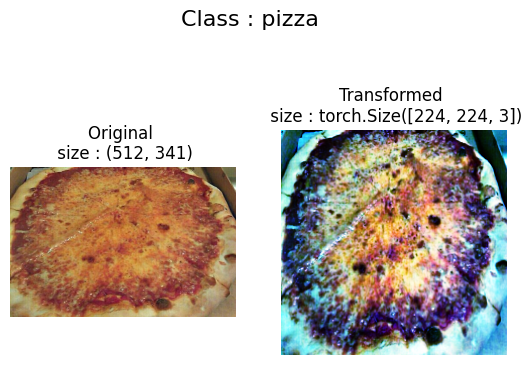

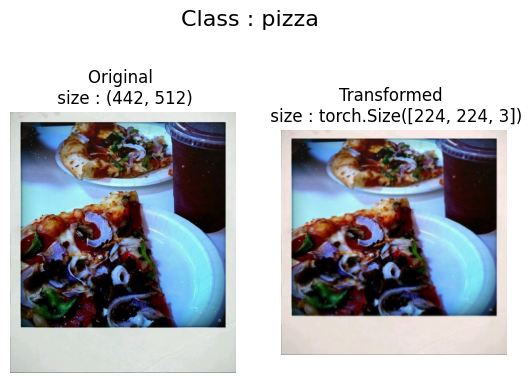

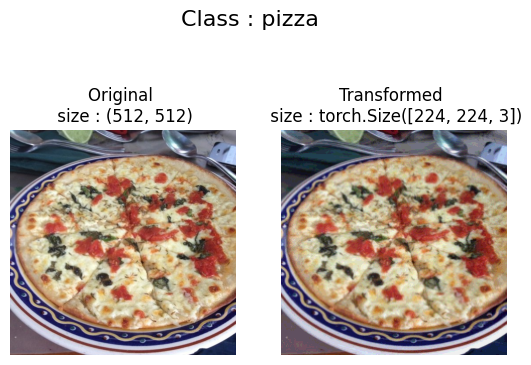

In [36]:
plot_transformed_images(images_dir = train_dir/"pizza",
                        transform = train_transform_aug,
                        n=3,
                        seed= None)

Time to create base model


In [37]:
simple_transform = transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.ToTensor()])

In [38]:
from torchvision import datasets
import os
from torch.utils.data import DataLoader

train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform, target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform, target_transform=None)

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_simple = DataLoader(dataset=train_data_simple, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
train_dataloader_simple, test_dataloader_simple


(<torch.utils.data.dataloader.DataLoader at 0x7c470c0e5420>,
 <torch.utils.data.dataloader.DataLoader at 0x7c470c0e56c0>)

Create Tiny VVG model class

In [39]:
last_layer_size = 16*16

class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3,stride=1 ,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1 ,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3,stride=1 ,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1 ,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*last_layer_size, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    #This codeblock is used to find last_layer_size
    # x = self.conv_block_1(x)
    # print(x.shape)
    # x = self.conv_block_2(x)
    # print(x.shape)
    # return self.classifier(x)

    return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [40]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_simple.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [42]:
# dummy foward pass on a single image (to test the model)

image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape , label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [43]:
model_0(image_batch.to(device)) # this used to determine the last_layer_size

tensor([[0.0637, 0.0615, 0.0382],
        [0.0598, 0.0601, 0.0385],
        [0.0661, 0.0620, 0.0389],
        [0.0679, 0.0707, 0.0401],
        [0.0657, 0.0643, 0.0402],
        [0.0557, 0.0571, 0.0356],
        [0.0610, 0.0599, 0.0372],
        [0.0740, 0.0676, 0.0400],
        [0.0660, 0.0652, 0.0366],
        [0.0603, 0.0623, 0.0397],
        [0.0623, 0.0627, 0.0368],
        [0.0576, 0.0614, 0.0391],
        [0.0673, 0.0616, 0.0385],
        [0.0639, 0.0597, 0.0395],
        [0.0702, 0.0663, 0.0405],
        [0.0621, 0.0613, 0.0361],
        [0.0690, 0.0665, 0.0397],
        [0.0733, 0.0687, 0.0412],
        [0.0565, 0.0611, 0.0366],
        [0.0630, 0.0564, 0.0428],
        [0.0613, 0.0612, 0.0382],
        [0.0644, 0.0620, 0.0405],
        [0.0642, 0.0620, 0.0386],
        [0.0609, 0.0612, 0.0382],
        [0.0614, 0.0590, 0.0377],
        [0.0579, 0.0600, 0.0380],
        [0.0688, 0.0647, 0.0378],
        [0.0584, 0.0609, 0.0384],
        [0.0624, 0.0603, 0.0378],
        [0.067

In [44]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model_0, input_size=(32, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

In [45]:
def train_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              device: torch.device):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      y_pred_class = torch.argmax(torch.softmax(test_pred_logits, dim=1), dim=1)
      test_acc += (y_pred_class == y).sum().item()/len(y_pred_class)

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc



In [46]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn = nn.CrossEntropyLoss(),
          epochs : int =  5,
          device: torch.device=None):
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []
             }

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                      dataloader=train_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer,
                                      device=device)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results






Time to do it

In [47]:
train_optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
torch.manual_seed(42)
from timeit import default_timer as timer
start_time = timer()

training_model_0_results = train(model=model_0,
                              train_dataloader=train_dataloader_simple,
                              test_dataloader=test_dataloader_simple,
                              optimizer=train_optimizer,
                              epochs=20,
                              device=device)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1071 | train_acc: 0.2500 | test_loss: 1.1061 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0784 | train_acc: 0.4258 | test_loss: 1.1396 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0804 | train_acc: 0.4258 | test_loss: 1.1698 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1282 | train_acc: 0.3047 | test_loss: 1.1594 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0889 | train_acc: 0.4258 | test_loss: 1.1443 | test_acc: 0.2604
Epoch: 6 | train_loss: 1.0962 | train_acc: 0.3047 | test_loss: 1.1456 | test_acc: 0.2604
Epoch: 7 | train_loss: 1.0850 | train_acc: 0.4336 | test_loss: 1.1422 | test_acc: 0.1979
Epoch: 8 | train_loss: 1.0954 | train_acc: 0.2930 | test_loss: 1.1466 | test_acc: 0.1979
Epoch: 9 | train_loss: 1.0872 | train_acc: 0.3711 | test_loss: 1.1109 | test_acc: 0.3210
Epoch: 10 | train_loss: 1.0353 | train_acc: 0.4727 | test_loss: 1.0373 | test_acc: 0.5256
Epoch: 11 | train_loss: 0.9539 | train_acc: 0.6211 | test_loss: 1.0586 | test_acc: 0.3428
Epoch: 12 | train_l

time to plot the loss curves

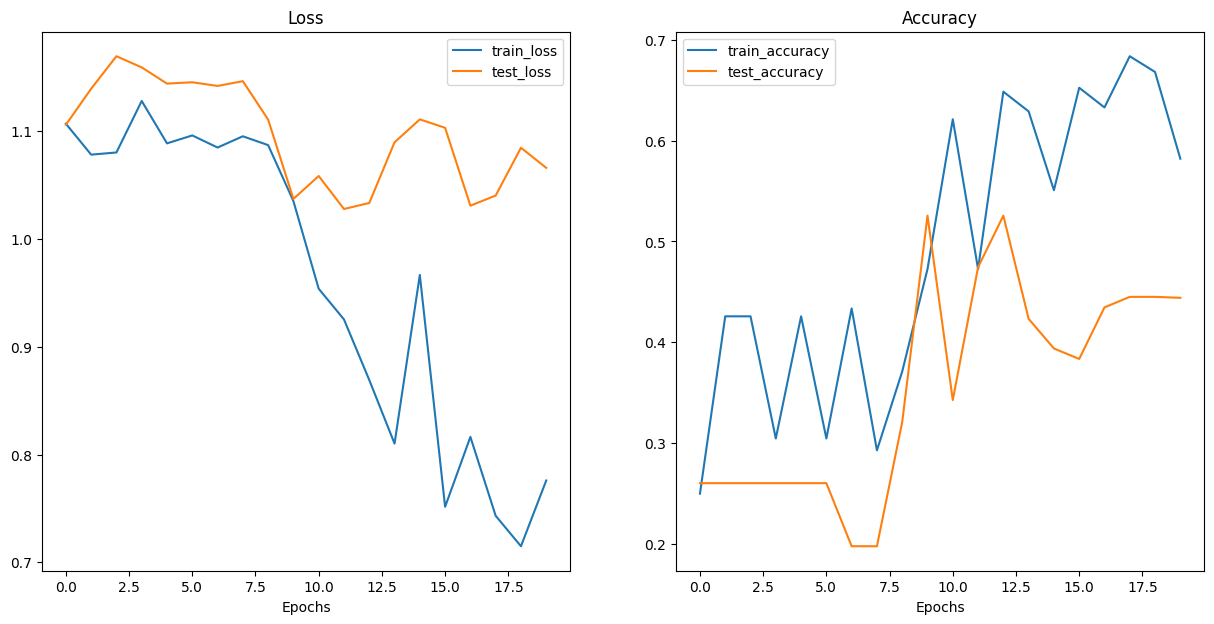

In [48]:
def plot_loss_curves(results):
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()
  plt.show()


plot_loss_curves(training_model_0_results)

Well the plot clearly shows that the model is overfittng. To reduce overfitting, we could try augmenting the data

In [51]:
train_transform_trivial = transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.TrivialAugmentWide( num_magnitude_bins=31),
                                      transforms.ToTensor()])

train_data_trivial = datasets.ImageFolder(root=train_dir, transform=train_transform_trivial, target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform, target_transform=None)

In [54]:
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
torch.manual_seed(42)
train_dataloader_trivial = DataLoader(dataset=train_data_trivial, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
train_dataloader_trivial, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x7c470b9da830>,
 <torch.utils.data.dataloader.DataLoader at 0x7c47a47d2a10>)

In [55]:
model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_trivial.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [56]:

start_time = timer()
train_optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)
torch.manual_seed(42)
training_model_1_results = train(model=model_1,
                              train_dataloader=train_dataloader_trivial,
                              test_dataloader=test_dataloader_simple,
                              optimizer=train_optimizer,
                              epochs=20,
                              device=device)

end_time = timer()
print(f"Total training time : {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1076 | train_acc: 0.2500 | test_loss: 1.1062 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0791 | train_acc: 0.4258 | test_loss: 1.1387 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0810 | train_acc: 0.4258 | test_loss: 1.1696 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1292 | train_acc: 0.3047 | test_loss: 1.1625 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0899 | train_acc: 0.4258 | test_loss: 1.1482 | test_acc: 0.2604
Epoch: 6 | train_loss: 1.0953 | train_acc: 0.3047 | test_loss: 1.1437 | test_acc: 0.2604
Epoch: 7 | train_loss: 1.0874 | train_acc: 0.4023 | test_loss: 1.1391 | test_acc: 0.1979
Epoch: 8 | train_loss: 1.1062 | train_acc: 0.2930 | test_loss: 1.1491 | test_acc: 0.1979
Epoch: 9 | train_loss: 1.1202 | train_acc: 0.3281 | test_loss: 1.1534 | test_acc: 0.3021
Epoch: 10 | train_loss: 1.0744 | train_acc: 0.5234 | test_loss: 1.0900 | test_acc: 0.3220
Epoch: 11 | train_loss: 1.0563 | train_acc: 0.4453 | test_loss: 1.0569 | test_acc: 0.5246
Epoch: 12 | train_l

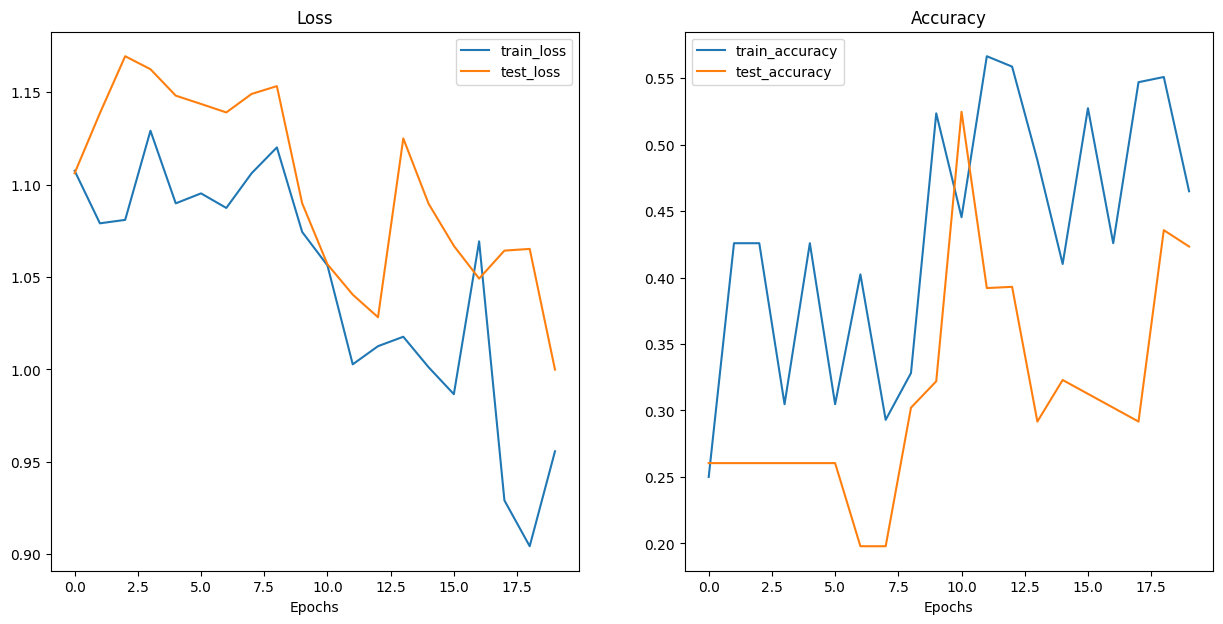

In [57]:
plot_loss_curves(training_model_1_results)

In [59]:
import pandas as pd
model_df_1= pd.DataFrame(training_model_1_results)
model_df_0=pd.DataFrame(training_model_0_results)
model_df_0

,train_loss,train_acc,test_loss,test_acc
0,1.107118,0.250000,1.106103,0.260417
1,1.078403,0.425781,1.139569,0.260417
2,1.080416,0.425781,1.169756,0.260417
3,1.128219,0.304688,1.159371,0.260417
4,1.088865,0.425781,1.144343,0.260417
5,1.096243,0.304688,1.145591,0.260417
6,1.084995,0.433594,1.142173,0.197917
7,1.095441,0.292969,1.146597,0.197917
8,1.087237,0.371094,1.110929,0.321023
9,1.035305,0.472656,1.037340,0.525568


<function matplotlib.pyplot.subplot(*args, **kwargs) -> 'Axes'>

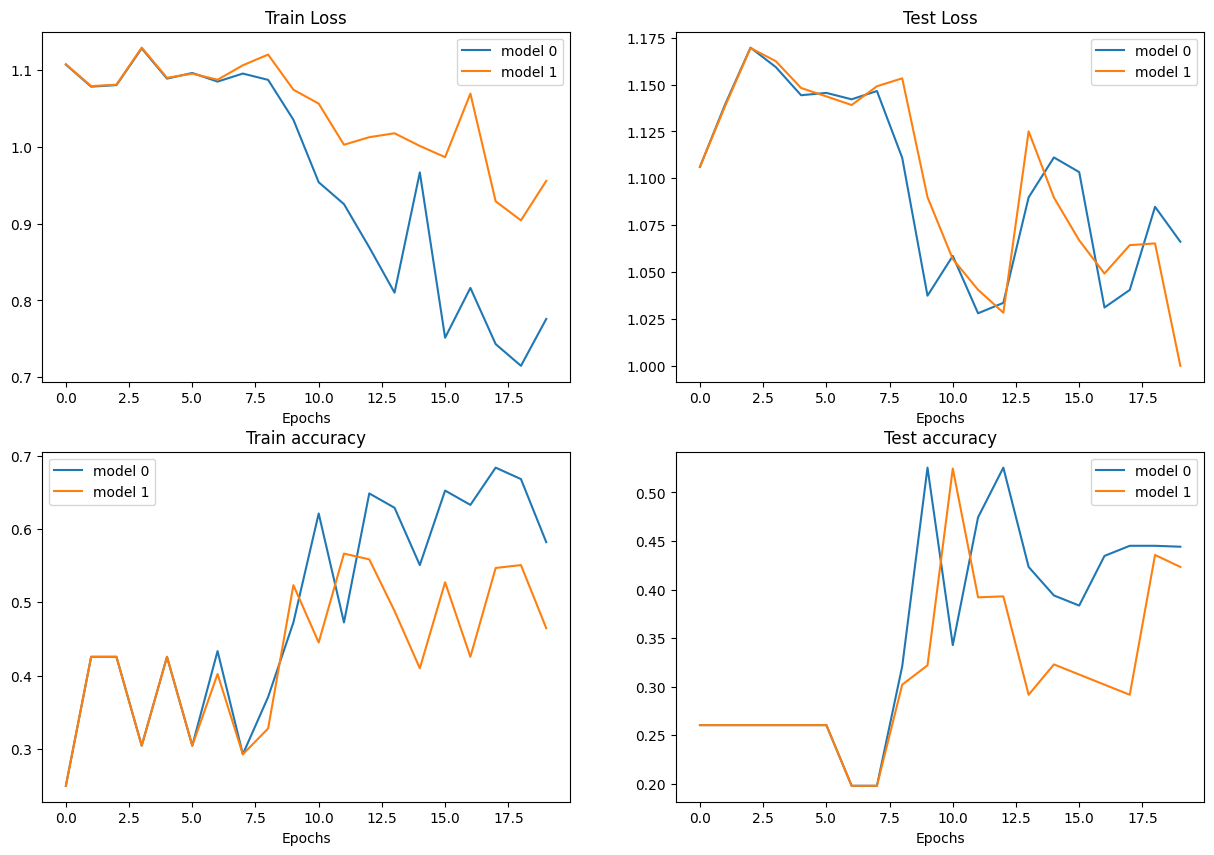

In [66]:
plt.figure(figsize=(15, 10))
epochs = range(len(model_df_0))
plt.subplot(2, 2, 1)
plt.plot(epochs, model_df_0["train_loss"], label="model 0")
plt.plot(epochs, model_df_1["train_loss"], label="model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()
plt.subplot

plt.subplot(2, 2, 2)
plt.plot(epochs, model_df_0["test_loss"], label="model 0")
plt.plot(epochs, model_df_1["test_loss"], label="model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()
plt.subplot

plt.subplot(2, 2, 3)
plt.plot(epochs, model_df_0["train_acc"], label="model 0")
plt.plot(epochs, model_df_1["train_acc"], label="model 1")
plt.title("Train accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.subplot

plt.subplot(2, 2, 4)
plt.plot(epochs, model_df_0["test_acc"], label="model 0")
plt.plot(epochs, model_df_1["test_acc"], label="model 1")
plt.title("Test accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.subplot